# OLX Ko'chmas mulk — Malumot Tozalash jaroyoni  
Kodni tepadan paga qarab yurg'azing. Oxirida sizda tayor `cleaned.csv` fileli modeling uchun tayor bo'ladi.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

In [3]:
df = pd.read_csv('../data/Praperad/olx_apartments.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded: 83,091 rows, 29 columns


In [4]:
df.isna().sum()

listing_id             0
source                 0
seller_type            1
housing_type       28978
region                 1
district               1
rooms                  1
living_area_m2     55270
kitchen_area_m2    63577
total_area_m2         12
floor                  3
total_floors           1
building_type      20640
layout             29712
build_year         58035
ceiling_height     53058
bathroom           23271
furnished              5
renovation         15729
commission             1
amenities          30391
nearby             27121
negotiable             0
price                204
currency               0
published_date         1
description            1
date_scraped           0
url                    0
dtype: int64

In [5]:
df.head()

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
0,4jYx9,olx,private,resale,Tashkent Region,Chilanzar District,1.0,20.0,6.0,29.0,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",1,60000.0,USD,01/05/2026,Описание Уй локацияси зур жойда жойлашган. Мир...,2026-05-02,https://www.olx.uz/d/obyavlenie/1-hona-metro-o...
1,4myoT,olx,private,NaN,Tashkent Region,Yunusabad District,2.0,80.0,NaN,80.0,...,1.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,7865000.0,UZS,30/04/2026,Описание Сдается в аренду 2/6/13 Юнусабад 13 к...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
2,4lvjL,olx,business,new building,Tashkent Region,Yunusabad District,3.0,NaN,NaN,80.0,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, School, Playground, Kinderga...",0,220000.0,USD,29/04/2026,Описание Продается квартира !!! 3/6/9 80 кВ По...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-prodae...
3,4aiOy,olx,private,NaN,Tashkent Region,Shaykhantakhur District,3.0,67.5,NaN,67.5,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...",NaN,0,1400.0,USD,02/05/2026,"Описание Квартира в новостройке Tashkent City,...",2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
4,4mAGS,olx,business,resale,Tashkent Region,Yashnabad District,3.0,50.0,NaN,78.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,120000.0,USD,02/05/2026,Описание Продается своя квартира 3/1/4 Кирпичн...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-3-1-4...


## A. Malumotna uchun shartnoma

# Ma'lumotlar lug'ati — OLX.uz kvartiralar dataseti
 
> **Hajmi:** 83 000+ qator × 28 ustun  
> **Manba:** OLX.uz — kvartiralar bo'limi (`/nedvizhimost/kvartiry/`)  
> **Skraping sanasi:** 2026-04-15 - hozir

## B. Ma'lumotlarni qabul qilish va dastlabki tekshiruvlar

### B.1. Asosiy qabul qilish ro'yxati:

In [6]:
print(f'File nomi: olx_apartments.csv')
print(f'Qatorlar soni: {df.shape[0]}')
print(f'Ustunlar soni: {df.shape[1]}')
print(f"Ustun nomlari malumot ustuniga o'xshashmimi: (Ha/yoq): Ha")

File nomi: olx_apartments.csv
Qatorlar soni: 83091
Ustunlar soni: 29
Ustun nomlari malumot ustuniga o'xshashmimi: (Ha/yoq): Ha


### B.2. Noyoblik + dublikatlar (Dunyo talabi)

In [7]:
before = len(df)
after = df.duplicated().sum()
print(f"Dublikatlar soni: {after}")
print(f'Noyoblik soni: {before-after}')
df_cleaned = df.drop_duplicates()

Dublikatlar soni: 3269
Noyoblik soni: 79822


### B.3. Natija yaxlitligini tekshirish
  
>Faqatgina ko'zlangan malumonni o'z ichaga oladimi? (yani narxni)  
* 2 hil turdaki valyuta aralashgan UZB va USD.
>Biror yoqolgan qiymatlar bormi?
* Bor 50 rotiq
>G‘alati yozilgan (imlosi noto‘g‘ri) so‘zlar bormi?
* Hozircha kuzatilmadi

## C. Malumot sifati (Nima hato ekanligini isbotlash)
  
### C.1. Yetishmayotgan Qiymatlar Profili
 
**Dataset hajmi:** 18,267 qator (`price` ustunidagi 40 ta bo'sh qiymat o'chirilgandan keyin)
 
---
 
## Yetishmayotgan Qiymatlar Jadvali
 
| Ustun | Yetishmaydi (n) | % | Qabul qilinadimi? | Nega yetishmayotgan bo'lishi mumkin? |
|---|---|---|---|---|
| listing_id | 0 | 0.0% | ✅ Ha | — |
| seller_type | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| housing_type | 5,956 | 32.6% | ⚠️ Balki | Forma to'ldirishda majburiy emas |
| region | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| district | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| rooms | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| living_area_m2 | 12,862 | 70.4% | ❌ Yo'q | Sotuvchilar ko'pincha maydon ma'lumotini qoldirmaydi |
| kitchen_area_m2 | 14,775 | 80.9% | ❌ Yo'q | Alohida ko'rsatilmaydi; ixtiyoriy maydon |
| total_area_m2 | 4 | 0.0% | ✅ Ha | Deyarli to'liq |
| floor | 2 | 0.0% | ✅ Ha | Deyarli to'liq |
| total_floors | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| building_type | 4,488 | 24.6% | ⚠️ Balki | Sotuvchi har doim bilmasligi mumkin |
| layout | 6,378 | 34.9% | ⚠️ Balki | Ixtiyoriy maydon; subyektiv tasnif |
| build_year | 13,785 | 75.5% | ❌ Yo'q | Eski binolarda hujjat yo'q bo'lishi mumkin |
| ceiling_height | 12,486 | 68.4% | ❌ Yo'q | E'lonlarda kamdan-kam ko'rsatiladi |
| bathroom | 5,057 | 27.7% | ⚠️ Balki | Ko'p formatlarda ixtiyoriy |
| furnished | 3 | 0.0% | ✅ Ha | Deyarli to'liq |
| renovation | 3,370 | 18.4% | ⚠️ Balki | Sotuvchi ta'mirlash holatini ko'rsatmasligi mumkin |
| commission | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| amenities | 7,045 | 38.6% | ⚠️ Balki | Ixtiyoriy maydon; har doim to'ldirilmaydi |
| nearby | 6,523 | 35.7% | ⚠️ Balki | Ixtiyoriy qo'shimcha maydon |
| negotiable | 0 | 0.0% | ✅ Ha | — |
| price | 40 | 0.2% | ❌ Yo'q | Maqsad ustun — to'liq bo'lishi shart; o'chirildi |
| currency | 0 | 0.0% | ✅ Ha | — |
| published_date | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| description | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| date_scraped | 0 | 0.0% | ✅ Ha | — |
| url | 0 | 0.0% | ✅ Ha | — |
 
---
 
## Yetishmayotgan Qiymatlar Tahlili
 
### Yetishmayotgan qiymatlar tasodifiy yoki tizimliymi?
 
Bu datasetdagi yetishmayotgan qiymatlar **to'liq tasodifiy emas**. `living_area_m2` (70.4%), `kitchen_area_m2` (80.9%), `build_year` (75.5%) va `ceiling_height` (68.4%) ustunlarida qiymatlarning aksariyati yo'q. Bu **tizimli muammo**ni ko'rsatadi: ushbu maydonlar platforma formasida ixtiyoriy bo'lgan yoki sotuvchilar ularni to'ldirishni istamagan.
 
### Yetishmayotgan qiymatlar narx (price) bilan bog'liqmi?
 
Jismoniy xususiyatlari (maydon, qurilish yili, shift balandligi) ko'rsatilmagan e'lonlar **past sifatli yoki norasmiy** bo'lishi mumkin, bu esa narxlarning ham past bo'lishiga olib keladi. Agar shunday bo'lsa, bu ustunlarni o'rtacha qiymat bilan to'ldirish (imputation) **narx bashoratlarini yuqori tomonga siljitishi** mumkin.
 
### Guruhlar bo'yicha yetishmayotgan % ni tekshirish (tavsiya)
 
```python
# housing_type bo'yicha yetishmayotgan %
df.groupby('housing_type').apply(lambda x: x.isnull().mean() * 100)
 
# region bo'yicha yetishmayotgan %
df.groupby('region').apply(lambda x: x.isnull().mean() * 100)
```
 
### Xulosa
 
Yetishmayotgan qiymatlar **qisman tizimli** xarakterga ega: `living_area_m2`, `kitchen_area_m2`, `build_year` va `ceiling_height` ustunlarida 68–81% qiymat yo'q, chunki platforma ularni ixtiyoriy maydon sifatida ko'rsatadi. Bu oddiy xato emas — bu sotuvchilarning e'lon to'ldirishdagi tarkibiy kamchiligidir. Modellashtirish oldidan ushbu ustunlar uchun qaror qabul qilish kerak: **ustunlarni o'chirish**, **ehtiyotkorlik bilan to'ldirish (imputation)**, yoki **yetishmayotganlikni alohida belgi (binary flag) sifatida saqlash**.

### Amal qiladigan oralag'i columnlar uchun
  
---
 
| Ustun | Ma'nosi | Turi | Mumkin qiymatlar / diapazon | O'lchov birligi | Izohlar |
| --- | --- | --- | --- | --- | --- |
| `listing_id` | E'lon unikal identifikatori | string | `'4jYx9'` kabi 5 belgili alfanumerik kod | — | OLX tomonidan avtomatik beriladi; asosiy kalit (primary key) sifatida ishlatiladi |
| `seller_type` | Sotuvchi turi | kategoriya | `private`, `business` | — | `private` — uy egasi o'zi; `business` — agentlik yoki firma |
| `housing_type` | Uy-joy turi | kategoriya | `resale`, `new building` | — | 2 834 ta qiymat yo'q; ko'pchilik `resale` |
| `region` | Viloyat | kategoriya | `Tashkent Region` va boshqa viloyatlar | — | Hozirgi ma'lumotlarda asosan Toshkent viloyati |
| `district` | Tuman / mahalla | kategoriya | `Chilanzar District`, `Yunusabad District` va boshqalar | — | Narx prognozi uchun eng muhim ustunlardan biri |
| `rooms` | Xonalar soni | raqam | `1` — `6+` | dona | Butun son kutiladi; modelda kategoriya sifatida ham ishlatish mumkin |
| `living_area_m2` | Yashash maydoni | raqam | taxminan `10` — `200` | m² | 5 777 ta qiymat yo'q (66%); mediana bilan to'ldirish + `missing` flagi tavsiya etiladi |
| `kitchen_area_m2` | Oshxona maydoni | raqam | taxminan `4` — `30` | m² | 6 656 ta qiymat yo'q (76%); yuqori yo'qotish darajasi |
| `total_area_m2` | Umumiy maydon | raqam | taxminan `15` — `500` | m² | Faqat 1 ta qiymat yo'q; narx prognozi uchun asosiy ustun |
| `floor` | Qavat | raqam | `1` — `30+` | qavat | 1 ta qiymat yo'q; mediana bilan to'ldirish yetarli |
| `total_floors` | Binodagi jami qavatlar soni | raqam | `2` — `30+` | qavat | Qiymat yo'q emas; `floor / total_floors` nisbati yaratish tavsiya etiladi |
| `building_type` | Bino turi | kategoriya | `panel`, `brick`, `monolith` | — | 2 029 ta qiymat yo'q; eng ko'p uchraydigan qiymat bilan to'ldirish |
| `layout` | Xonalar tartibi | kategoriya | `adjacent`, `separate`, `Смежно-раздельная` | — | Aralash til (rus/ingliz) bor — tozalash kerak; 2 840 ta qiymat yo'q |
| `build_year` | Qurilgan yil | raqam | `1950` — `2026` | yil | 6 197 ta qiymat yo'q; `building_age = 2026 - build_year` ustuni hosil qilish tavsiya etiladi |
| `ceiling_height` | Shift balandligi | raqam | `2.5` — `4.0` | metr | 5 683 ta qiymat yo'q; mediana bilan to'ldirish |
| `bathroom` | Hammom turi | kategoriya | `separate`, `combined` | — | 2 312 ta qiymat yo'q; eng ko'p uchraydigan qiymat bilan to'ldirish |
| `furnished` | Mebel mavjudligi | ikkilik (binary) | `1` — mebel bor, `0` — yo'q | — | Faqat 2 ta qiymat yo'q |
| `renovation` | Ta'mirlash holati | kategoriya | `euro renovation`, `average condition`, `designer renovation` | — | 1 538 ta qiymat yo'q; narxga sezilarli ta'sir ko'rsatadi |
| `commission` | Vositachi komissiyasi | ikkilik (binary) | `0` — yo'q, `1` — bor | — | Qiymat yo'q emas; `1` bo'lsa agentlik orqali sotiladi |
| `amenities` | Jihozlar ro'yxati | vergul bilan ajratilgan string | `Internet`, `TV`, `Air Conditioning`, `Balcony`, `Washing Machine` va boshqalar | — | 3 187 ta qiymat yo'q = jihozlar ko'rsatilmagan; multi-hot encoding tavsiya etiladi |
| `nearby` | Yaqin atrofdagi ob'ektlar | vergul bilan ajratilgan string | `School`, `Bus Stop`, `Park`, `Hospital`, `Supermarket` va boshqalar | — | 2 874 ta qiymat yo'q; multi-hot encoding tavsiya etiladi |
| `negotiable` | Narx kelishiladi | ikkilik (binary) | `1` — ha, `0` — yo'q | — | Qiymat yo'q emas |
| `price` | Narx | raqam | `500` — `2 000 000` (USDga o'tkazilgandan keyin) | USD yoki UZS | 13 ta qiymat yo'q — bu qatorlarni o'chirish kerak; avval valyutani normallashtirish shart |
| `currency` | Valyuta | kategoriya | `USD`, `UZS` | — | Modelga kirishdan oldin hammasi USDga aylantiriladi (1 USD ≈ 12 700 UZS) |
| `published_date` | E'lon joylashtirilgan sana | sana | `DD/MM/YYYY` formatida | sana | Modelda `days_since_posted` ustuniga aylantirish mumkin |
| `description` | E'lon matni | erkin matn | Rus va o'zbek tillarida | — | Modelga kiritilmaydi; NLP tahlili uchun alohida ishlatish mumkin |
| `date_scraped` | Skraping sanasi | sana | `YYYY-MM-DD` formatida | sana | Barcha qatorlarda `2026-05-02`; modelda ishlatilmaydi |
| `url` | E'lon havolasi | string | `https://www.olx.uz/d/obyavlenie/...` | — | Modelda ishlatilmaydi; manba sifatida saqlab qo'yish tavsiya etiladi |
 
---
 
## Tozalash bo'yicha qisqacha yo'riqnoma
 
| Muammo | Ta'sirlangan ustunlar | Yechim |
| --- | --- | --- |
| Maqsadli qiymat yo'q | `price` (13 ta) | Qatorlarni o'chirish |
| Yuqori yo'qotish (>50%) | `living_area_m2`, `kitchen_area_m2`, `build_year`, `ceiling_height` | Mediana bilan to'ldirish + `_missing` flagi |
| O'rtacha yo'qotish | `housing_type`, `building_type`, `layout`, `bathroom`, `renovation` | Eng ko'p uchraydigan qiymat (mode) bilan to'ldirish |
| Aralash valyuta | `price`, `currency` | Hammasi USDga o'tkazish |
| Aralash til | `layout` | `Смежно-раздельная` → `mixed` deb standartlashtirish |
| Vergul bilan ajratilgan qiymatlar | `amenities`, `nearby` | Multi-hot encoding (har bir teg — alohida ustun) |

## D. Tozalash strategiyasi (nafaqat qadamlar-qarorlar)
  
### D.1 Standartlashtirish qoidalari (kategoriyaviy)
`seller_type` --> Faqatgina 2 dona categoria aniqlandi. Ortiqcha tekshiruv talab qilmaydi.  
`housing_type` --> 6 ga yaqin categoria aniqladi. Uchta rus tilodagi miqdorlar("новостройка", "Новостройка", "Новостройка.") --> new building  
`region` -- > Hammasi joyida.


In [8]:
df_cleaned['district'].value_counts()

district
Mirzo-Ulugbek District       12576
Yunusabad District            9121
Yakkasaray District           8115
Mirabad District              7560
Yashnabad District            7488
                             ...  
Обмен - Учтепинский район        1
Бешарык                          1
Зиадин                           1
Талимарджан                      1
Заамин                           1
Name: count, Length: 189, dtype: int64

---

## Price malumot tozalash

In [9]:
df_cleaned[df_cleaned['price'].isnull()]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
1314,4mwtN,olx,private,NaN,Tashkent Region,Бектемирский район,3.0,45.0,12.0,66.0,...,0.0,"Internet, Refrigerator, TV, Cable TV, Washing ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,NaN,USD,29/04/2026,Описание Musaffo maskan 3/6/10 400$ ichida ha...,2026-05-02,https://www.olx.uz/d/obyavlenie/musaffo-maskan...
2126,4ms7L,olx,business,NaN,Tashkent Region,Mirzo-Ulugbek District,2.0,56.0,NaN,56.0,...,1.0,NaN,NaN,1,NaN,USD,01/05/2026,Описание Мирзо-Улугбекский район ЖК Akay City ...,2026-05-02,https://www.olx.uz/d/obyavlenie/akay-city-2-ko...
3926,4mCMT,olx,business,new building,Tashkent Region,Yashnabad District,2.0,NaN,NaN,60.0,...,1.0,NaN,NaN,0,NaN,USD,02/05/2026,Описание Срочно Продаётся Новостройка 2 комнат...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-novost...
4431,4mCEI,olx,business,NaN,Tashkent Region,Yashnabad District,2.0,NaN,NaN,52.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, Playground, Kindergarten, Bu...",1,NaN,USD,02/05/2026,Описание Район: Яшнабод Ориентир: Better best ...,2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-kvartir...
4624,4lDkg,olx,business,NaN,Обмен - Ферганская область,Обмен - Маргилан,3.0,56.0,15.0,56.0,...,0.0,"Telephone, Cable TV, TV, Internet","Entertainment, Bus Stop, School, Supermarket, ...",0,NaN,USD,02/05/2026,Описание Ijaraga beriladi yoki hovli uyga bart...,2026-05-02,https://www.olx.uz/d/obyavlenie/dom-ijaraga-be...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78690,4mTXg,olx,private,NaN,Tashkent Region,Yakkasaray District,1.0,15.0,9.0,30.0,...,0.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,NaN,USD,06/06/2026,Описание Я хозяйка квартиры сдам в аренду свою...,2026-06-06,https://www.olx.uz/d/obyavlenie/metro-novza-kv...
79082,4ol7g,olx,business,new building,Tashkent Region,Yashnabad District,3.0,NaN,NaN,97.0,...,1.0,NaN,NaN,0,NaN,USD,06/06/2026,Описание ПРОДAЖA - Квартира #Новостройка ID: 3...,2026-06-06,https://www.olx.uz/d/obyavlenie/srochno-gorit-...
80638,4oak9,olx,business,NaN,Tashkent Region,Mirzo-Ulugbek District,2.0,NaN,NaN,36.0,...,1.0,NaN,NaN,0,NaN,USD,10/06/2026,Описание 370+150 депозит и 150000 комуналка Тт...,2026-06-10,https://www.olx.uz/d/obyavlenie/srochno-arenda...
81511,4obgc,olx,business,NaN,Обмен - Ташкент,Обмен - Мирабадский район,2.0,NaN,NaN,40.0,...,0.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,NaN,USD,10/06/2026,Описание СРОЧНО ПРОДАЁТСЯ 2-КОМНАТНАЯ КВАРТИРА...,2026-06-10,https://www.olx.uz/d/obyavlenie/srochnaya-prod...


In [10]:
df_cleaned[df_cleaned['currency'] == "UZS"]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
1,4myoT,olx,private,NaN,Tashkent Region,Yunusabad District,2.0,80.0,NaN,80.0,...,1.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,7865000.0,UZS,30/04/2026,Описание Сдается в аренду 2/6/13 Юнусабад 13 к...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
24,49bVu,olx,private,NaN,Samarkand Region,Лаиш,2.0,65.0,NaN,10.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",0,4000000.0,UZS,02/05/2026,Описание Samarqand shahar Qorasuv massiv 2 xon...,2026-05-02,https://www.olx.uz/d/obyavlenie/bez-agestvo-ij...
29,4lwkw,olx,private,NaN,Khorezm Region,Ургенч,3.0,49.0,10.0,62.0,...,0.0,"Refrigerator, TV, Air Conditioning, Washing Ma...","Hospital, Clinic, School, Playground, Kinderga...",0,2800000.0,UZS,02/05/2026,Описание Ургенч шахар марказида мед институтга...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-izhar...
30,3nWuH,olx,private,resale,Samarkand Region,Samarkand,5.0,86.0,12.0,100.0,...,0.0,"Kitchen, Balcony","Hospital, Clinic, Playground, Kindergarten, Bu...",0,900000000.0,UZS,02/05/2026,Описание 5 хона 6 хона килинган квартира сотил...,2026-05-02,https://www.olx.uz/d/obyavlenie/6-honalik-kvar...
33,3It0w,olx,private,NaN,Tashkent Region,Yashnabad District,4.0,100.0,12.0,92.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","School, Playground, Kindergarten, Bus Stop, Pa...",1,1300000.0,UZS,02/05/2026,"Описание Квартирага боллани куяман, 1.300 000...",2026-05-02,https://www.olx.uz/d/obyavlenie/kvartiraga-ish...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82995,4oy6v,olx,private,NaN,Tashkent Region,Ахангаран,2.0,40.0,12.0,52.0,...,0.0,"Refrigerator, TV, Kitchen","Hospital, Clinic, Playground, Kindergarten, Bu...",1,3000000.0,UZS,10/06/2026,Описание Uzoq muddatli ijaraga 2 xonali xonado...,2026-06-10,https://www.olx.uz/d/obyavlenie/ijaraga-2-xona...
82996,4oy6x,olx,business,NaN,Tashkent Region,Yashnabad District,1.0,50.0,40.0,60.0,...,0.0,"Refrigerator, Washing Machine, Kitchen","Hospital, Clinic, Kindergarten, Park, Green Ar...",0,2500000.0,UZS,10/06/2026,Описание Сдаем аренду 1 комнату с хозяйкой для...,2026-06-10,https://www.olx.uz/d/obyavlenie/sdaem-arendu-1...
83033,4n5YG,olx,private,new building,Tashkent Region,Sergeli District,1.0,14.0,4.0,20.0,...,0.0,"Cable TV, Balcony","Hospital, Clinic, School, Playground, Kinderga...",0,70000000.0,UZS,10/06/2026,"Описание Sergeli tumanida ""Yangi Hayot ""majmua...",2026-06-10,https://www.olx.uz/d/obyavlenie/juda-zor-imkon...
83081,4oy4u,olx,private,NaN,Khorezm Region,Янгиарык,3.0,65.0,20.0,80.0,...,0.0,"Internet, Telephone, Refrigerator, TV, Kitchen","Hospital, Clinic, Playground, Kindergarten, Bu...",0,1500000.0,UZS,10/06/2026,Описание Янгиарик тумани марказида имтис кучад...,2026-06-10,https://www.olx.uz/d/obyavlenie/3-honali-uy-iz...


In [11]:
# Birinchi bo'lib narxi yo'q qatorlarni olib tashlaymiz
before1 = len(df_cleaned['price'])
df_cleaned.dropna(subset=['price'], inplace=True)
print(f"Qatorlar soni(Dublikat bilan): {before1}")
print(f"Olib tashlangan qator soni: {before1 - len(df_cleaned['price'])}")
print(f"Noyoblik soni: {len(df_cleaned['price'])}")

# Endi bir xil valyutaga o'tqazib olamiz
exchange_rate = 12700
df_cleaned['price_usd'] = df_cleaned['price']
df_cleaned.loc[df_cleaned['currency']=="UZS", 'price_usd'] = (
    df_cleaned.loc[df_cleaned['currency']=="UZS", 'price_usd'] / exchange_rate
).round(1)

Qatorlar soni(Dublikat bilan): 79822
Olib tashlangan qator soni: 192
Noyoblik soni: 79630


/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_22956/3476733231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(subset=['price'], inplace=True)
/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_22956/3476733231.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['price_usd'] = df_cleaned['price']


Hozirda 3 savdo turdaki uylar OLXda joylngan.  
Bu muammo OLX tomonidan amalga oshirilgan bo'lishi mumkin va natijada bu malumotni tozalash qiyinchiligiga olip keladi.  
Bu muammoni yechish uch ikki turdaki yechim mavjud. Biri narx orqali savdo turini aniqlash va ikkinchi esa commetaria orqali.

In [12]:
df_cleaned.loc[(df_cleaned['price_usd'] < 30000) & (df_cleaned['price_usd'] > 3000), ["price_usd","description"]]

,price_usd,description
14,29000.0,Описание Продаётся 2х комнатная квартира в хор...
42,14173.2,Описание Нокис каласы Коскол 3 жолға жакын 4 х...
59,22440.9,Описание Квартира сотилади 45 м² 2 хона + кухн...
73,25196.9,Описание SROCHNA SOTILADI PUL ZARUR parkentda ...
88,26200.0,Описание Текстил Бурж аптека енида жойлашган 4...
...,...,...
82953,24000.0,Описание Navastroyka 7 etaj qolganini telefon...
83008,27500.0,Описание Хоналар сони: #1х Кават: 5 Уйнинг кав...
83033,5511.8,"Описание Sergeli tumanida ""Yangi Hayot ""majmua..."
83047,12500.0,Описание Дом бир хона сотилади олмазор ситида...


In [13]:
df_cleaned[(df_cleaned['price_usd'] > 3000) & (df_cleaned['price_usd'] < 5000)]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url,price_usd
310,4iYGx,olx,business,NaN,Tashkent Region,Mirabad District,4.0,NaN,NaN,230.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,4499.0,USD,01/05/2026,Описание Срочно Сдаётся Новостройка Ж/К Mirab...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-sdaets...,4499.0
1430,4lZm3,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,NaN,NaN,190.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,3500.0,USD,29/04/2026,Описание 20.04.2026 • Район: Мирабад • Мирабад...,2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-zhk-mir...,3500.0
1510,4mvif,olx,private,NaN,Tashkent Region,Алмазарский район,3.0,70.0,20.0,80.00,...,"Air Conditioning, Refrigerator, Washing Machin...","Restaurant, Cafe, Kindergarten, Parking, Bus S...",0,3490.0,USD,02/05/2026,"Описание Нестван А блок 40 этаж, этажность 51 ...",2026-05-02,https://www.olx.uz/d/obyavlenie/nestone-a-blok...,3490.0
1623,4lGcq,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,180.0,NaN,200.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,4000.0,USD,29/04/2026,"Описание -Реальная цена, реальные фото -14.04....",2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-kvartir...,4000.0
1724,4locg,olx,private,NaN,Tashkent Region,Mirabad District,3.0,240.0,40.0,300.00,...,NaN,NaN,0,3500.0,USD,08/04/2026,Описание Роскошная вилла в корейском стиле сда...,2026-05-02,https://www.olx.uz/d/obyavlenie/elitnaya-kvart...,3500.0
3479,3riNq,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,220.0,NaN,220.00,...,"Kitchen, TV, Balcony, Air Conditioning, Intern...","Restaurant, Cafe, Kindergarten, Parking, Bus S...",0,3500.0,USD,02/05/2026,Описание Сдаётся Квартира в центре Габусе #О...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-kvart...,3500.0
5753,4mDuc,olx,private,new building,Tashkent Region,Yunusabad District,1.0,29.0,NaN,29.00,...,"Internet, Cable TV, Balcony","Hospital, Clinic, Playground, Kindergarten, Bu...",0,3500.0,USD,02/05/2026,"Описание Юнусабад, Бетонка, ориентир Уч Кахрам...",2026-05-02,https://www.olx.uz/d/obyavlenie/1-komnatnaya-k...,3500.0
6101,4kQpz,olx,business,NaN,Tashkent Region,Mirabad District,4.0,NaN,NaN,200.00,...,NaN,NaN,1,4000.0,USD,02/05/2026,Описание Мирабадский район Жк Mirabad Avenue П...,2026-05-02,https://www.olx.uz/d/obyavlenie/mirabad-avenue...,4000.0
11642,3WTjS,olx,business,NaN,Tashkent Region,Mirzo-Ulugbek District,7.0,400.0,15.0,400.00,...,"Telephone, Cable TV, Internet, Air Conditionin...","School, Supermarket, Shops, Park, Green Area, ...",0,4000.0,USD,03/05/2026,"Описание Сдается 7комната 2этажность 400кв, 7к...",2026-05-03,https://www.olx.uz/d/obyavlenie/sdaetsya-7komn...,4000.0
12475,4mGnz,olx,private,NaN,Navoiy Region,Navoiy,3.0,94.0,4.0,94.00,...,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,40000000.0,UZS,03/05/2026,Описание 3 хона 1 етаж полностью абстанофка иж...,2026-05-03,https://www.olx.uz/d/obyavlenie/srochna-izhara...,3149.6


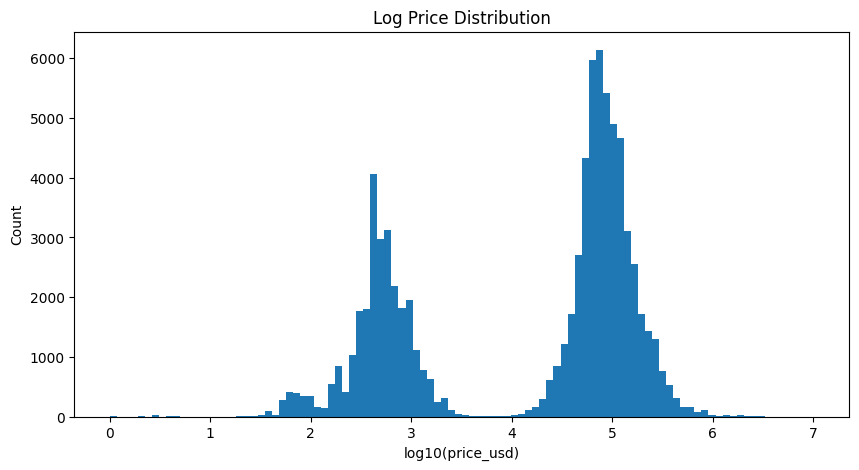

In [14]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned["price_usd"] + 1), bins=100)
plt.xlabel("log10(price_usd)")
plt.ylabel("Count")
plt.title("Log Price Distribution")
plt.show()

In [15]:
df_cleaned["listing_type"] = "Unknown"

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_22956/13968768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["listing_type"] = "Unknown"


In [16]:
import re

RENT_MAX_PRICE = 2000
SALE_MIN_PRICE = 10000

def listing_type_scores(df):
    desc = df["description"].fillna("").str.lower()
    url = df["url"].fillna("").str.lower()

    rent_words = [
        "сдаётся", "сдается", "сдам", "сдаю", "аренда", "аренду",
        "посуточно", "помесячно",
        "ижарага", "ижара", "ijaraga", "ijara", "ijaraga beriladi",
        "topshiriladi", "арендага",
        "for rent", "to rent", "lease", "tenant"
    ]

    sale_words = [
        "продаётся", "продается", "продам", "продаю", "продажа",
        "сотилади", "sotiladi", "sotaman", "sotuv", "sotish",
        "ипотека", "рассрочка", "ipoteka",
        "for sale", "sell", "selling", "mortgage"
    ]


    rent_score = (
        sum(desc.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in rent_words) * 3
        + sum(url.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in rent_words)
    )

    sale_score = (
        sum(desc.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in sale_words) * 3
        + sum(url.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in sale_words)
    )

    return rent_score, sale_score


def classify_listings(df):
    rent_score, sale_score = listing_type_scores(df)
    price = df["price_usd"]

    conditions = [
        (sale_score > rent_score) & (price >= RENT_MAX_PRICE),
        (rent_score > sale_score) & (price < SALE_MIN_PRICE),
        (sale_score > rent_score) & (price < RENT_MAX_PRICE),
        (rent_score > sale_score) & (price >= SALE_MIN_PRICE),
        price >= SALE_MIN_PRICE,
    ]

    choices = ["Sale", "Rent", "Rent", "Sale", "Sale"]

    return np.select(conditions, choices, default="Rent")


df_cleaned["listing_type"] = classify_listings(df_cleaned)

# Sanity check
rent_score, sale_score = listing_type_scores(df_cleaned)

print(df_cleaned["listing_type"].value_counts())
print(f"\nAmbiguous both-hit rows: {((rent_score > 0) & (sale_score > 0)).sum()}")
print(f"No keyword rows: {((rent_score == 0) & (sale_score == 0)).sum()}")

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_22956/2076063578.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["listing_type"] = classify_listings(df_cleaned)


listing_type
Sale    51556
Rent    28074
Name: count, dtype: int64

Ambiguous both-hit rows: 1533
No keyword rows: 32760


In [17]:
df_cleaned["price_per_sqr"] = np.nan

sale_mask = (
    (df_cleaned["listing_type"] == "Sale") &
    (df_cleaned["total_area_m2"].notna()) &
    (df_cleaned["total_area_m2"] > 0)
)

df_cleaned.loc[sale_mask, "price_per_sqr"] = round(
    (df_cleaned.loc[sale_mask, "price_usd"] /
    df_cleaned.loc[sale_mask, "total_area_m2"]
), 2)

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_22956/324250605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["price_per_sqr"] = np.nan


In [18]:
MAX_PRICE_PER_SQR = 50000

df_cleaned = df_cleaned[
    ~(
        (df_cleaned["listing_type"] == "Sale") &
        (df_cleaned["price_per_sqr"] > MAX_PRICE_PER_SQR)
    )
].copy()

---

## `listing_id` malumot tozalash

In [19]:
print(f"listing_id dublikatlar soni: {len(df_cleaned)-len(df_cleaned['listing_id'].unique())}")

listing_id dublikatlar soni: 261


Qaysidir sabab orqali `listing_id` o'z ichiga dublikatlarni oladi.

In [20]:
print(f"Dublikatlar soni: {len(df_cleaned)}")
df_cleaned = df_cleaned.drop_duplicates(subset=['listing_id'])
print(f'Noyoblik soni dublikatlarni olib tashlangandam keyin: {len(df_cleaned)}')

Dublikatlar soni: 79557
Noyoblik soni dublikatlarni olib tashlangandam keyin: 79296


In [21]:
df_cleaned[df_cleaned.duplicated(subset='listing_id', keep=False)].sort_values(by = 'listing_id')

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,negotiable,price,currency,published_date,description,date_scraped,url,price_usd,listing_type,price_per_sqr


---

## `seller_type` tozalash jarayoni

In [22]:
df_cleaned['seller_type'].isna().sum()

np.int64(0)

seller_type column toza va hech qanday xatolar mavjud emas


---

## `housing_type`  malumot tozalash

In [23]:
df_cleaned['housing_type'].value_counts()

housing_type
new building               28113
resale                     23637
Новостройка                    7
новостройка                    3
От застройщика                 2
Новостройка.                   1
Кирпич                         1
Вторичка,кирпичный дом.        1
Name: count, dtype: int64

In [24]:
print(f"missing - {round(df_cleaned['housing_type'].isna().sum()/len(df_cleaned)*100, 2)}%")

missing - 34.72%


In [25]:
valid_housing_type = {
    'new building': 'new building',
    'resale': 'resale',
    'Новостройка': 'new building',
    'новостройка': 'new building',
    'Новостройка.': 'new building',
    'Вторичка,кирпичный дом.': 'new building'
}

def validate_housing_type(text):
    if pd.isna(text):
        return np.nan

    if text in valid_housing_type:
        return valid_housing_type[text]
    else:
        return np.nan

    return text

df_cleaned['housing_type'] = df_cleaned['housing_type'].apply(validate_housing_type)

In [26]:
df_cleaned['housing_type'].value_counts()

housing_type
new building    28125
resale          23637
Name: count, dtype: int64

---

## `region` malumot tozalash

In [27]:
df_cleaned['region'].value_counts()

region
Tashkent Region               69266
Samarkand Region               3624
Bukhara Region                 3171
Navoiy Region                   808
Fergana Region                  798
Khorezm Region                  407
Kashkadarya Region              365
Republic of Karakalpakstan      209
Surxondaryo Region              176
Andijan Region                  163
Jizzakh Region                  128
Sirdaryo Region                 105
Namangan Region                  76
Name: count, dtype: int64

In [28]:
df_cleaned['region'].isna().sum()

np.int64(0)

Region column toza. 

----


## `district` tozalash jarayoni

In [29]:
df_cleaned['district'].value_counts()

district
Mirzo-Ulugbek District    12542
Yunusabad District         9064
Yakkasaray District        8083
Mirabad District           7532
Yashnabad District         7431
                          ...  
Турткуль                      1
Камаши                        1
Иштыхан                       1
Пахтаабад                     1
Заамин                        1
Name: count, Length: 174, dtype: int64

In [30]:
district_list = df_cleaned['district'].value_counts().index.to_list()

In [31]:
print(district_list)

['Mirzo-Ulugbek District', 'Yunusabad District', 'Yakkasaray District', 'Mirabad District', 'Yashnabad District', 'Chilanzar District', 'Shaykhantakhur District', 'Sergeli District', 'Samarkand', 'Алмазарский район', 'Bukhara', 'Uchtepa District', 'Чирчик', 'Мирабад', 'Фергана', 'Navoiy', 'Бектемирский район', 'Карши', 'Алмалык', 'Ургенч', 'Эшангузар', 'Нукус', 'Янгиюль', 'Нурафшан (Тойтепа)', 'Термез', 'Зангиата', 'Андижан', 'Кибрай', 'Зарафшан', 'Келес', 'Каган', 'Джизак', 'Караул', 'Гулистан', 'Назарбек', 'Наманган', 'Ангрен', 'Ахангаран', 'Коканд', 'Янги Маргилан', 'Бекабад', 'Чарвак', 'Коксарай', 'Шахрисабз', 'Уртааул', 'Хива', 'Янгибазар', 'Учкудук', 'Маргилан', 'Красногорск', 'Искандар', 'Галаасия', 'Газалкент', 'Паркент', 'Каттакурган', 'Гиждуван', 'Учтепа', 'Джамбай', 'Гюлабад', 'Булунгур', 'Кувасай', 'Салар', 'Кармана', 'Бука', 'Аккурган', 'Ромитан', 'Сардоба', 'Кызылтепа', 'Канимех', 'Лаиш', 'Тамдыбулак', 'Шафиркан', 'Китаб', 'Куйганъяр', 'Пахтакор', 'Янгиабад', 'Карасу', 'Т

In [32]:
district_overrides = {
    # Tashkent city districts
    "mirzo-ulugbek district": "Mirzo Ulugbek",
    "yunusabad district": "Yunusabad",
    "yakkasaray district": "Yakkasaray",
    "mirabad district": "Mirabad",
    "yashnabad district": "Yashnabad",
    "chilanzar district": "Chilanzar",
    "shaykhantakhur district": "Shaykhantakhur",
    "sergeli district": "Sergeli",
    "uchtepa district": "Uchtepa",

    "алмазарский район": "Almazar",
    "бектемирский район": "Bektemir",
    "мирабад": "Mirabad",
    "учтепа": "Uchtepa",

    # Existing Latin names
    "samarkand": "Samarkand",
    "bukhara": "Bukhara",
    "navoiy": "Navoiy",
}

cyrillic_to_latin = {
    "а": "a", "б": "b", "в": "v", "г": "g", "д": "d",
    "е": "e", "ё": "yo", "ж": "zh", "з": "z", "и": "i",
    "й": "y", "к": "k", "л": "l", "м": "m", "н": "n",
    "о": "o", "п": "p", "р": "r", "с": "s", "т": "t",
    "у": "u", "ф": "f", "х": "kh", "ц": "ts", "ч": "ch",
    "ш": "sh", "щ": "shch", "ъ": "", "ы": "y", "ь": "",
    "э": "e", "ю": "yu", "я": "ya",

    # Uzbek Cyrillic
    "ў": "o", "қ": "q", "ғ": "g", "ҳ": "h",
}

def transliterate(text):
    return "".join(cyrillic_to_latin.get(ch, ch) for ch in text)

def normalize_place_name(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "" or "css" in value.lower():
        return np.nan

    key = value.lower().strip()

    if key in district_overrides:
        return district_overrides[key]

    # Remove generic words
    key = key.replace(" district", "")
    key = key.replace(" район", "")
    key = key.replace("ский", "")
    key = key.replace("ская", "")
    key = key.replace("ское", "")

    # Transliterate Cyrillic to Latin
    key = transliterate(key)

    # Clean spacing
    key = re.sub(r"\s+", " ", key).strip()

    # Title case, keeping hyphenated names readable
    return key.title()

In [33]:
df_cleaned["district"] = df_cleaned["district"].apply(normalize_place_name)

df_cleaned["district"].sort_values().unique()

array(['Akhangaran', 'Akhunbabaev', 'Akkurgan', 'Aktash', 'Alat',
       'Almalyk', 'Almazar', 'Altyaryk', 'Andizhan', 'Angor', 'Angren',
       'Asaka', 'Bagat', 'Bagdad', 'Bakht', 'Bekabad', 'Bektemir',
       'Beruni', 'Besharyk', 'Beshkent', 'Beshrabat', 'Bolshoy Chimgan',
       'Buka', 'Bukhara', 'Bulakbashi', 'Bulungur', 'Bustan', 'Chalysh',
       'Chartak', 'Charvak', 'Chilanzar', 'Chilek', 'Chimbay', 'Chinaz',
       'Chirakchi', 'Chirchik', 'Chust', 'Darband', 'Dekhkanabad',
       'Denau', 'Durmen', 'Dustabad', 'Dzhambay', 'Dzharkurgan',
       'Dzhizak', 'Dzhuma', 'Eshanguzar', 'Fergana', 'Galaasiya',
       'Gallaaral', 'Gazalkent', 'Gazli', 'Gizhduvan', 'Gulbakhor',
       'Gulistan', 'Gurlen', 'Guzalkent', 'Guzar', 'Gyulabad',
       'Ishtykhan', 'Iskandar', 'Kagan', 'Kamashi', 'Kanimekh',
       'Kanlykul', 'Karakul', 'Karasu', 'Karaul', 'Karaulbazar',
       'Karmana', 'Karshi', 'Kasan', 'Kattakurgan', 'Keles', 'Khanabad',
       'Khanka', 'Khazarasp', 'Khiva', 'Khodz

----


## `rooms` tozalash jarayoni

In [34]:
df_cleaned['rooms'].value_counts()

rooms
2.0      33282
3.0      24431
1.0      11344
4.0       7746
5.0       1781
         ...  
165.0        1
53.0         1
123.0        1
67.0         1
44.0         1
Name: count, Length: 64, dtype: int64

In [35]:
df_cleaned_1 = df_cleaned[df_cleaned['rooms'] < 7].copy()

In [36]:
df_cleaned_1['rooms'].value_counts()

rooms
2.0    33282
3.0    24431
1.0    11344
4.0     7746
5.0     1781
6.0      344
Name: count, dtype: int64

Man 6 xonadan katta bo'lgan barcha elonlarni olib tashlashga qaror qildim.  
Kuzatuvlarga asoslanib shuni ayta olamanki. 6+ xonadonlar soni 500 ga yaqin va ularning ko'pchiligi xaqiqatga yaqin emas.

----

## `living_area_m2` tozalash jarayoni

In [37]:
print(f"missing: {round((df_cleaned_1['living_area_m2'].isna().sum()/len(df_cleaned_1['living_area_m2']))*100)}")

missing: 67


Raughly 68% of data is missing.

In [38]:
df_cleaned_1['living_area_m2'].describe()

count    26317.00000
mean        62.43288
std         47.20473
min          1.00000
25%         40.00000
50%         56.00000
75%         73.00000
max        999.00000
Name: living_area_m2, dtype: float64

Natijaga asoslanib shuni ayta olamizki `living_area_m2` judaham ishlatishga yaroqsiz.  
OLX `living_area_m2` ni optional qilib qoygan shu sabali `68 foiz` data bo'sh qoldirilgan.  
Judaham ko'b sotuvchilar taxminan to'ldirgan bo'lishlari mumkin.  
Katta extimollik bilan `living_area_m2` analysisda va predictive model uchun yaroqsis.

In [39]:
df_cleaned_1 = df_cleaned_1.drop(columns=['living_area_m2'])

---

## `kitchen_area_m2` Tozalash jarayoni

In [40]:
print(f"missing: {round((df_cleaned_1['kitchen_area_m2'].isna().sum()/len(df_cleaned_1['kitchen_area_m2']))*100)}")

missing: 77


In [41]:
df_cleaned_1['kitchen_area_m2'].describe()

count    18409.000000
mean        17.092897
std         43.823201
min          0.300000
25%          8.000000
50%         12.000000
75%         15.000000
max        999.000000
Name: kitchen_area_m2, dtype: float64

78% data to'ldirilmagan.  
Natijaga asoslanganda shu aniqki kiritilga raqamlar xaqiqatga yaqin emas.  


In [42]:
df_cleaned_1 = df_cleaned_1.drop(columns="kitchen_area_m2")

---

## `total_area_m2` Tozalash jarayoni

In [43]:
print(f"missing: {(df_cleaned_1['total_area_m2'].isna().sum()/len(df_cleaned_1['total_area_m2']))*100}")

missing: 0.012669774984796269


In [44]:
df_cleaned_1['total_area_m2'].describe()

count    78918.000000
mean        71.011962
std         44.218802
min          1.000000
25%         50.000000
50%         63.000000
75%         80.000000
max        999.000000
Name: total_area_m2, dtype: float64

In [45]:
df_cleaned_1=df_cleaned_1.dropna(subset=['total_area_m2'])

Q1 = df_cleaned_1['total_area_m2'].quantile(0.25)
Q3 = df_cleaned_1['total_area_m2'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower boundary: {lower}")
print(f"Upper boundary: {upper}")

Lower boundary: 5.0
Upper boundary: 125.0


In [46]:
df_cleaned_1.loc[df_cleaned_1['total_area_m2']>125.0, ["total_area_m2","price_usd"]]

,total_area_m2,price_usd
11,150.0,180000.0
20,240.0,800.0
42,600.0,14173.2
80,220.0,1500.0
89,128.0,165000.0
...,...,...
83039,150.0,1500.0
83040,150.0,1200.0
83050,600.0,1250000.0
83054,500.0,2050000.0


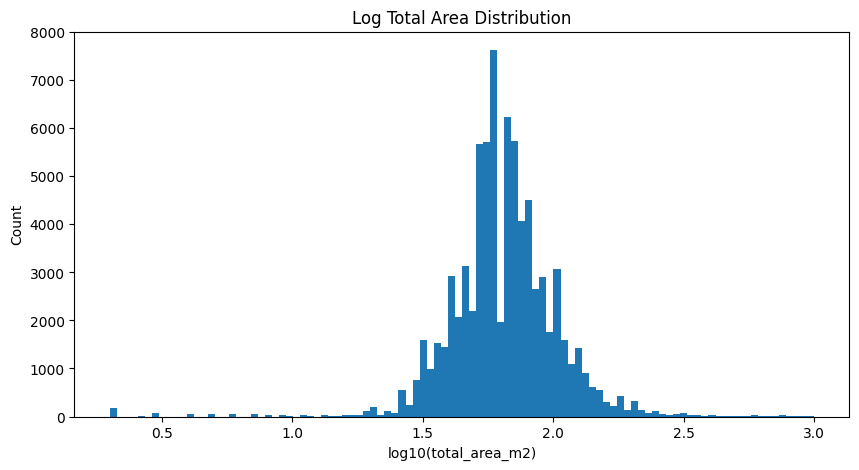

In [47]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['total_area_m2']+1), bins=100)
plt.xlabel("log10(total_area_m2)")
plt.ylabel("Count")
plt.title("Log Total Area Distribution")
plt.show()


In [48]:
lower = max(lower, 10)
upper = 400

df_cleaned_1 = df_cleaned_1[
    df_cleaned_1['total_area_m2'].between(lower, upper)
]

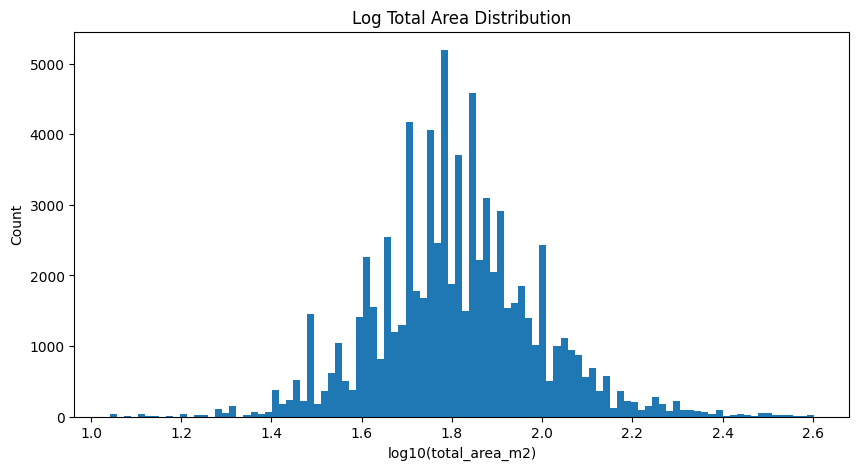

In [49]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['total_area_m2']+1), bins=100)
plt.xlabel("log10(total_area_m2)")
plt.ylabel("Count")
plt.title("Log Total Area Distribution")
plt.show()

In [50]:
print(len(df_cleaned_1))

78230


## `floor` & `total_floors` Tozalash jarayoni

In [51]:
df_cleaned_1['floor'].describe()

count    78228.000000
mean         4.856420
std          3.944554
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max        120.000000
Name: floor, dtype: float64

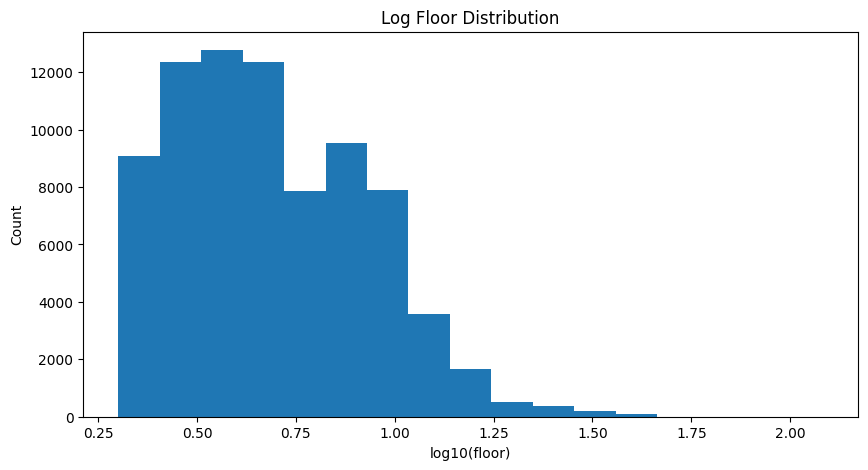

In [52]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['floor']+1),bins=17)
plt.xlabel("log10(floor)")
plt.ylabel("Count")
plt.title("Log Floor Distribution")
plt.show()

In [53]:
df_cleaned_1['floor'].value_counts()


floor
3.0      12771
2.0      12363
4.0      12353
1.0       9069
5.0       7846
6.0       4807
7.0       4734
8.0       4419
9.0       3467
10.0      1799
12.0       901
11.0       880
13.0       475
14.0       466
15.0       431
16.0       281
17.0       146
18.0       146
20.0        93
23.0        92
22.0        92
24.0        68
21.0        66
19.0        64
25.0        48
34.0        40
27.0        39
31.0        37
32.0        32
26.0        30
35.0        27
30.0        22
40.0        17
37.0        13
39.0        13
33.0        12
29.0        11
42.0        11
36.0         8
44.0         7
38.0         6
43.0         5
45.0         4
28.0         4
47.0         3
60.0         2
63.0         2
67.0         1
48.0         1
54.0         1
55.0         1
61.0         1
120.0        1
Name: count, dtype: int64

In [54]:
df_cleaned_1.loc[df_cleaned_1['floor'] > 30, ["price_usd","total_area_m2", "rooms", "floor", "total_floors","url"]]

,price_usd,total_area_m2,rooms,floor,total_floors,url
634,2200.0,120.0,3.0,34.0,51.0,https://www.olx.uz/d/obyavlenie/zhk-nest-one-s...
786,165000.0,65.0,2.0,31.0,48.0,https://www.olx.uz/d/obyavlenie/uspey-kupit-2-...
951,155000.0,59.0,2.0,37.0,48.0,https://www.olx.uz/d/obyavlenie/srochno-nedoro...
1433,280000.0,64.0,2.0,35.0,48.0,https://www.olx.uz/d/obyavlenie/prodaetsya-shi...
1510,3490.0,80.0,3.0,40.0,51.0,https://www.olx.uz/d/obyavlenie/nestone-a-blok...
...,...,...,...,...,...,...
82664,228000.0,100.0,3.0,32.0,49.0,https://www.olx.uz/d/obyavlenie/prodaetsya-3h-...
82714,315000.0,60.0,3.0,39.0,51.0,https://www.olx.uz/d/obyavlenie/prodaetsya-3ko...
82875,370000.0,92.0,3.0,33.0,51.0,https://www.olx.uz/d/obyavlenie/prodaetsya-3h-...
82910,220000.0,66.0,2.0,42.0,57.0,https://www.olx.uz/d/obyavlenie/kvartira-na-pi...


In [55]:
df_cleaned_1 = df_cleaned_1[df_cleaned_1['floor'] < 100]

In [56]:
df_cleaned_1["total_floors"].value_counts()

total_floors
4.0      18039
9.0      14816
5.0      10920
10.0      5208
7.0       4352
         ...  
74.0         1
60.0         1
46.0         1
650.0        1
57.0         1
Name: count, Length: 64, dtype: int64

In [57]:
df_cleaned_1 = df_cleaned_1[df_cleaned_1['total_floors'] < 100]

## `building_type` tozalash jarayoni 

In [58]:
df_cleaned_1["building_type"].value_counts()

building_type
brick                                                         35397
panel                                                         14154
monolith                                                       7730
block                                                          1377
Деревянный                                                      146
Панель                                                           24
панель-середина                                                  12
кирпич                                                            5
Панельный Планировка: Раздельный                                  5
.css-cgp8kk{border-top:1px solid #7F9799;margin-top:24px;}        5
Монолит                                                           4
монолит                                                           1
монолитная                                                        1
77-серия, имеется 6м балкон                                       1
кирпичный дом                     

In [59]:
df_cleaned_1.isna().sum()

listing_id            0
source                0
seller_type           0
housing_type      27006
region                0
district              0
rooms                 0
total_area_m2         0
floor                 0
total_floors          0
building_type     19354
layout            27938
build_year        54928
ceiling_height    50121
bathroom          21850
furnished             1
renovation        14676
commission            0
amenities         28632
nearby            25538
negotiable            0
price                 0
currency              0
published_date        0
description           0
date_scraped          0
url                   0
price_usd             0
listing_type          0
price_per_sqr     27412
dtype: int64

In [60]:
def clean_building_type(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if "css" in value:
        return np.nan

    if "кирп" in value or "brick" in value:
        return "brick"

    if "панел" in value or "panel" in value:
        return "panel"

    if "монолит" in value or "monolith" in value:
        return "monolith"

    if "блок" in value or "block" in value or "газоблок" in value:
        return "block"

    if "дерев" in value:
        return "wood"

    return np.nan

In [61]:
df_cleaned_1["building_type"] = df_cleaned_1["building_type"].apply(clean_building_type)

df_cleaned_1["building_type"].value_counts(dropna=False)

building_type
brick       35406
NaN         19360
panel       14196
monolith     7736
block        1378
wood          146
Name: count, dtype: int64

## `layout` tozalash jarayoni

In [62]:
df_cleaned_1['layout'].value_counts()

layout
separate                       38641
Смежно-раздельная               3884
adjacent                        3591
studio                          2561
Многоуровневая                   563
                               ...  
сквозная, без глухих комнат        1
середина (не угловая)              1
Смежные комнаты                    1
3/5/12                             1
студия.                            1
Name: count, Length: 97, dtype: int64

In [63]:
def clean_layout(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if value in ["-", ""]:
        return np.nan

    if "css" in value:
        return np.nan

    if "studio" in value or "студ" in value:
        return "studio"

    if "free layout" in value or "свобод" in value:
        return "free_layout"

    if "пентхаус" in value or "penthouse" in value:
        return "penthouse"

    if "многоуров" in value:
        return "multi_level"

    if "малосем" in value:
        return "small_family"

    if (
        "смежно" in value
        or "см-раз" in value
        or "см раз" in value
        or "сможно" in value
    ):
        return "adjacent_separate"

    if "смеж" in value:
        return "adjacent"

    if (
        "раздел" in value
        or "раздель" in value
        or "алоҳида" in value
        or "alohida" in value
        or value == "separate"
    ):
        return "separate"

    if "adjacent" in value:
        return "adjacent"

    return np.nan

df_cleaned_1["layout"] = df_cleaned_1["layout"].apply(clean_layout)

df_cleaned_1["layout"].value_counts(dropna=False)

layout
separate             38749
NaN                  28098
adjacent_separate     3898
adjacent              3674
studio                2567
multi_level            563
small_family           511
penthouse              160
free_layout              2
Name: count, dtype: int64

## `build_year` tozalash jarayoni

In [64]:
df_cleaned_1["build_year"].describe()

count    23294.000000
mean      2006.495020
std         15.959382
min       1960.000000
25%       1989.000000
50%       2015.000000
75%       2019.000000
max       2025.000000
Name: build_year, dtype: float64

In [65]:
df_cleaned_1[df_cleaned_1["build_year"].isna()]

,listing_id,source,seller_type,housing_type,region,district,rooms,total_area_m2,floor,total_floors,...,negotiable,price,currency,published_date,description,date_scraped,url,price_usd,listing_type,price_per_sqr
3,4aiOy,olx,private,NaN,Tashkent Region,Shaykhantakhur,3.0,67.5,5.0,6.0,...,0,1400.0,USD,02/05/2026,"Описание Квартира в новостройке Tashkent City,...",2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...,1400.0,Rent,NaN
4,4mAGS,olx,business,resale,Tashkent Region,Yashnabad,3.0,78.0,1.0,4.0,...,0,120000.0,USD,02/05/2026,Описание Продается своя квартира 3/1/4 Кирпичн...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-3-1-4...,120000.0,Sale,1538.46
8,4cXVi,olx,business,resale,Tashkent Region,Mirzo Ulugbek,1.0,28.0,4.0,5.0,...,0,65000.0,USD,02/05/2026,Описание Новомосковская 1комнатная кирпич Мирз...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-1-kom...,65000.0,Sale,2321.43
9,4mfGl,olx,business,new building,Tashkent Region,Yakkasaray,4.0,122.0,2.0,8.0,...,1,310000.0,USD,02/05/2026,Описание ПРОДАЕТСЯ 4/2/8 НОВОСТРОЙКА ЖК Dream ...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-novost...,310000.0,Sale,2540.98
10,4lw2N,olx,business,new building,Tashkent Region,Yakkasaray,4.0,108.0,4.0,8.0,...,1,240000.0,USD,02/05/2026,Описание Продаётся квартира ЖК Dream House #Як...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochnaya-prod...,240000.0,Sale,2222.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83074,4oy4X,olx,business,new building,Tashkent Region,Yunusabad,2.0,55.0,5.0,10.0,...,1,85000.0,USD,10/06/2026,Описание ПРОДАЁТСЯ! НОВОСТРОЙКА Юнусабад 8-ква...,2026-06-10,https://www.olx.uz/d/obyavlenie/yunusabad-8-kv...,85000.0,Sale,1545.45
83080,4oy4v,olx,business,new building,Tashkent Region,Yunusabad,1.0,40.0,2.0,8.0,...,1,62900.0,USD,10/06/2026,Описание Новостройка Юнусабад Застройщик: Када...,2026-06-10,https://www.olx.uz/d/obyavlenie/novostroyka-yu...,62900.0,Sale,1572.50
83082,4oc7N,olx,business,resale,Tashkent Region,Yunusabad,2.0,50.0,3.0,4.0,...,0,63000.0,USD,10/06/2026,Описание Продажа на ипотеку Юнусабад 7квартал ...,2026-06-10,https://www.olx.uz/d/obyavlenie/yunusabad-7kva...,63000.0,Sale,1260.00
83087,464lj,olx,private,NaN,Tashkent Region,Chilanzar,1.0,40.0,6.0,10.0,...,0,500.0,USD,09/06/2026,Описание Сдаю свою 1 комнатную квартиру в ново...,2026-06-10,https://www.olx.uz/d/obyavlenie/sdayu-svoyu-1-...,500.0,Rent,NaN


In [66]:
from datetime import datetime

current_year = datetime.now().year

df_cleaned_1["build_year"] = pd.to_numeric(df_cleaned_1["build_year"], errors="coerce")

df_cleaned_1["age"] = current_year - df_cleaned_1['build_year']

df_cleaned_1.loc[
    (df_cleaned_1["build_year"] < 1900) |
    (df_cleaned_1["build_year"] > current_year),
    "age"
] = np.nan


df_cleaned_1["age"].describe()

count    23294.000000
mean        19.504980
std         15.959382
min          1.000000
25%          7.000000
50%         11.000000
75%         37.000000
max         66.000000
Name: age, dtype: float64

In [67]:
df_cleaned_1.sample(5)

,listing_id,source,seller_type,housing_type,region,district,rooms,total_area_m2,floor,total_floors,...,price,currency,published_date,description,date_scraped,url,price_usd,listing_type,price_per_sqr,age
15358,4mpzV,olx,private,NaN,Fergana Region,Kuvasay,2.0,56.0,3.0,5.0,...,200.0,USD,04/05/2026,Описание Хамма шароитлари бор факат оилага бер...,2026-05-04,https://www.olx.uz/d/obyavlenie/izharaga-2hona...,200.0,Rent,NaN,NaN
36820,4mWBd,olx,private,NaN,Tashkent Region,Yashnabad,1.0,35.0,4.0,9.0,...,400.0,USD,08/05/2026,Описание 400$ Сдаю однокомнатную квартиру в Яш...,2026-05-08,https://www.olx.uz/d/obyavlenie/sdam-kvartiru-...,400.0,Rent,NaN,NaN
54593,4k222,olx,business,resale,Fergana Region,Fergana,3.0,85.0,2.0,4.0,...,40000.0,USD,13/05/2026,Описание Фаргона коленинский чуда маркет осиё ...,2026-05-13,https://www.olx.uz/d/obyavlenie/sotiladi-fargo...,40000.0,Sale,470.59,37.0
3540,4lwDQ,olx,business,resale,Tashkent Region,Yunusabad,2.0,55.0,1.0,5.0,...,78000.0,USD,02/05/2026,Описание Срочно!!! Продается квартира Юнусабад...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-yunuso...,78000.0,Sale,1418.18,37.0
20989,4mKqc,olx,private,new building,Tashkent Region,Yashnabad,3.0,80.0,1.0,5.0,...,95000.0,USD,04/05/2026,"Описание Продается своя квартира , новостройка...",2026-05-04,https://www.olx.uz/d/obyavlenie/svoya-1-1-1-5-...,95000.0,Sale,1187.50,NaN


## `ceiling_height` tozalash jarayoni

In [68]:
print(f"Missing values: {df_cleaned_1["ceiling_height"].isna().sum()}")

Missing values: 50121


In [69]:
print(df_cleaned_1["ceiling_height"].describe())

count    28101.000000
mean         3.015201
std          0.303723
min          2.000000
25%          3.000000
50%          3.000000
75%          3.000000
max          6.000000
Name: ceiling_height, dtype: float64


## `bathroom` tozalash jarayoni

In [70]:
print(df_cleaned_1['bathroom'].value_counts())

bathroom
separate                                                      28541
combined                                                      21477
2+ bathrooms                                                   6267
2                                                                32
3                                                                14
.css-cgp8kk{border-top:1px solid #7F9799;margin-top:24px;}        8
1                                                                 7
совмещеный                                                        2
Совмешенный                                                       2
Разделный                                                         2
Совмещённый.                                                      2
совмещение                                                        2
4                                                                 2
алоҳида                                                           2
2 санузла                              

In [71]:
def clean_bathroom(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip().replace(".", "")

    if value in ["", "-", "css"]:
        return np.nan

    if "css" in value:
        return np.nan

    if (
        value in ["2", "3", "4", "2 та"]
        or "2+" in value
        or "2 сан" in value
        or "2 та" in value
        or "3 сан" in value
        or "4 сан" in value
    ):
        return "2+ bathrooms"

    if (
        "separate" in value
        or "раздель" in value
        or "раздел" in value
        or "алоҳида" in value
        or "alohida" in value
    ):
        return "separate"

    if (
        "combined" in value
        or "совмещ" in value
        or "совмеш" in value
        or "совмещение" in value
    ):
        return "combined"

    return np.nan


df_cleaned_1["bathroom"] = df_cleaned_1["bathroom"].apply(clean_bathroom)

print(df_cleaned_1["bathroom"].value_counts(dropna=False))

bathroom
separate        28550
NaN             21867
combined        21486
2+ bathrooms     6319
Name: count, dtype: int64


## `furnished` tozalash jarayoni

In [72]:
df_cleaned_1["furnished"].value_counts()

furnished
1.0    59237
0.0    18984
Name: count, dtype: int64

## `renovation` tozalash jarayoni

In [73]:
df_cleaned_1["renovation"].value_counts()

renovation
euro renovation                                                                                       31392
average condition                                                                                     13184
designer renovation                                                                                   12125
shell and core                                                                                         2760
needs renovation                                                                                       2391
pre-finished                                                                                           1187
С ремонтом                                                                                              226
Евро                                                                                                    107
Без ремонта                                                                                              57
евро             

In [74]:
categories_list = df_cleaned_1["renovation"].value_counts().index.to_list()

In [75]:
print(categories_list)

['euro renovation', 'average condition', 'designer renovation', 'shell and core', 'needs renovation', 'pre-finished', 'С ремонтом', 'Евро', 'Без ремонта', 'евро', '.css-cgp8kk{border-top:1px solid #7F9799;margin-top:24px;}', 'Хороший', 'Среднее состояние', 'хороший', 'евро люкс', 'Коробка', 'коробка', 'комфорт, люкс', 'современный евро', 'Авторский/Дизайнерский', 'чистый ремонт', 'Дизайнерский', 'Евро | с мебелью и техникой', 'как на фото', 'Авторский ремонт', 'косметический', 'Новая никто не жил', 'дизайнерский', 'евро ремонт', 'новый, качественный', 'премиального класса, выполнен из качественных материалов', 'Черновая улучшенная', 'Евро ремонт', 'White Box', 'Авторский евроремонт в современном стиле. Использовались только качественные отделочные материалы.', 'ўртача', 'ўртача, тоза', 'Средний Ремонт', 'без ремонта', 'Требуется', 'новый ремонт', 'современный, выполнен в светлых тонах', 'комфорт, ҳали яшалмаган', 'Евро-Люкс', 'Евро авторские  дизайн (качественная отделка, квартира гото

In [76]:
def clean_renovation(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if value in ["", "-"]:
        return np.nan

    if "css" in value:
        return np.nan
    
    if value in ["йок", "йўқ", "yo'q", "yoq", "yuq", "yo‘q", "нет", "none", "no"]:
        return "needs_renovation"

    # No / needs renovation
    if (
        "без ремонта" in value
        or "требуется ремонт" in value
        or "needs renovation" in value
        or "ремонт керак" in value
    ):
        return "needs_renovation"

    # Shell/core / unfinished
    if (
        "shell" in value
        or "core" in value
        or "коробка" in value
        or "чернов" in value
    ):
        return "shell_and_core"

    # Pre-finished / white box
    if (
        "pre-finished" in value
        or "white box" in value
        or "предчист" in value
    ):
        return "pre_finished"

    # Designer / author renovation
    if (
        "designer" in value
        or "дизайнер" in value
        or "авторск" in value
        or "haytec" in value
    ):
        return "designer_renovation"

    # Euro / luxury / modern renovation
    if (
        "euro" in value
        or "евро" in value
        or "люкс" in value
        or "lux" in value
        or "современ" in value
        or "комфорт" in value
    ):
        return "euro_renovation"

    # Average / good condition
    if (
        "average" in value
        or "сред" in value
        or "хорош" in value
        or "яхши" in value
        or "чистый" in value
        or "космет" in value
        or "как на фото" in value
        or "с ремонтом" in value
        or value == "есть"
    ):
        return "average_condition"

    return np.nan

In [77]:
df_cleaned_1["renovation"] = df_cleaned_1["renovation"].apply(clean_renovation)

df_cleaned_1["renovation"].value_counts(dropna=False)

renovation
euro_renovation        31532
NaN                    14697
average_condition      13447
designer_renovation    12138
shell_and_core          2769
needs_renovation        2451
pre_finished            1188
Name: count, dtype: int64

## `commission` tozalash jarayoni

In [78]:
df_cleaned_1['commission'].value_counts()

commission
0.0    54011
1.0    24211
Name: count, dtype: int64

## `amenities` tozalash jarayoni

In [79]:
df_cleaned_1['amenities'].value_counts()

amenities
Internet, Telephone, Refrigerator, TV, Air Conditioning, Cable TV, Washing Machine, Kitchen, Balcony    16069
Kitchen, TV, Balcony, Air Conditioning, Internet, Cable TV, Telephone, Washing Machine, Refrigerator     2017
Kitchen, Balcony                                                                                         1862
Cable TV, TV, Telephone, Balcony, Washing Machine, Air Conditioning, Refrigerator, Internet, Kitchen     1845
Internet, Telephone, Refrigerator, TV, Air Conditioning, Cable TV, Washing Machine, Kitchen              1718
                                                                                                        ...  
Air Conditioning, Telephone, Washing Machine, Refrigerator, Internet                                        1
Washing Machine, Kitchen, Internet, Refrigerator                                                            1
TV, Balcony, Internet, Kitchen                                                                              1


## `nearby` tozalash jarayoni

In [80]:
df_cleaned_1['nearby'].value_counts()

nearby
Hospital, Clinic, Playground, Kindergarten, Bus Stop, Park, Green Area, Entertainment, Restaurant, Cafe, Parking, Supermarket, Shops, School    17869
Hospital, Clinic, School, Playground, Kindergarten, Bus Stop, Park, Green Area, Entertainment, Restaurant, Cafe, Parking, Supermarket, Shops    12030
Entertainment, Bus Stop, School, Supermarket, Shops, Restaurant, Cafe, Playground, Park, Green Area, Kindergarten, Hospital, Clinic, Parking     3534
Restaurant, Cafe, Kindergarten, Parking, Bus Stop, Hospital, Clinic, Supermarket, Shops, Park, Green Area, School, Entertainment, Playground     3533
Hospital, Clinic, Playground, Kindergarten, Bus Stop, Park, Green Area, Entertainment, Restaurant, Cafe, Parking, Supermarket, Shops             1171
                                                                                                                                                ...  
Hospital, Clinic, Kindergarten, Bus Stop, Restaurant, Cafe, Parking, Supermarket, Shops      

In [81]:
metro_pattern = r"metro|метро"

df_cleaned_1["near_metro_mentioned"] = (
    df_cleaned_1["description"].fillna("").str.contains(metro_pattern, case = False, regex = True) 
    |
    df_cleaned_1["url"].fillna("").str.contains(metro_pattern, case = False, regex = True)
).astype(int)

df_cleaned_1["near_metro_mentioned"].value_counts()


near_metro_mentioned
0    65133
1    13089
Name: count, dtype: int64

In [82]:
VALID_NEARBY = {
    "Hospital", "Clinic", "Playground", "Kindergarten", "Bus Stop",
    "Park", "Green Area", "Entertainment", "Restaurant", "Cafe",
    "Parking", "Supermarket", "Shops", "School", "Metro",
}

NEARBY_ALIASES = {
    "метро": "Metro",
    "metro": "Metro",
}

def clean_multi_value_items(value, valid_items=None):
    if pd.isna(value):
        return ""

    items = [item.strip() for item in str(value).split(",")]
    items = [NEARBY_ALIASES.get(item.lower(), item) for item in items]

    if valid_items is not None:
        items = [item for item in items if item in valid_items]

    return ", ".join(items)


def create_boolean_columns(df, column_name, prefix, valid_items=None):
    old_dummy_cols = [col for col in df.columns if col.startswith(f"{prefix}_")]
    df = df.drop(columns=old_dummy_cols, errors="ignore")

    cleaned_values = df[column_name].apply(
        lambda value: clean_multi_value_items(value, valid_items)
    )

    dummies = cleaned_values.str.get_dummies(sep=", ")

    dummies.columns = [
        f"{prefix}_{col.lower().strip().replace(' ', '_')}"
        for col in dummies.columns
    ]

    return pd.concat([df, dummies], axis=1)

In [83]:
df_cleaned_1 = create_boolean_columns(df_cleaned_1, "amenities", "amenity")
df_cleaned_1 = create_boolean_columns(df_cleaned_1, "nearby", "nearby", VALID_NEARBY)

In [84]:
df_cleaned_1.filter(like="amenity_").head()
df_cleaned_1.filter(like="nearby_").head()

,nearby_bus_stop,nearby_cafe,nearby_clinic,nearby_entertainment,nearby_green_area,nearby_hospital,nearby_kindergarten,nearby_metro,nearby_park,nearby_parking,nearby_playground,nearby_restaurant,nearby_school,nearby_shops,nearby_supermarket
0,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1
1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1


In [85]:
excel_apartment_cleaned = df_cleaned_1[[
    'listing_id',
    'url',

    'listing_type',
    'seller_type',
    'housing_type',

    'region',
    'district',

    'rooms',
    'total_area_m2',
    'price',
    'currency',
    'price_usd',
    'price_per_sqr',

    'floor',
    'total_floors',
    'building_type',
    'layout',
    'build_year',
    'age',
    'ceiling_height',

    'bathroom',
    'furnished',
    'renovation',
    'amenity_air_conditioning',
    'amenity_balcony',
    'amenity_cable_tv', 
    'amenity_internet', 
    'amenity_kitchen',
    'amenity_refrigerator', 
    'amenity_tv', 
    'amenity_telephone',
    'amenity_washing_machine', 
    'nearby_bus_stop', 
    'nearby_cafe',
    'nearby_clinic', 
    'nearby_entertainment', 
    'nearby_green_area',
    'nearby_hospital', 
    'nearby_kindergarten', 
    'nearby_park',
    'nearby_parking', 
    'nearby_playground', 
    'nearby_restaurant',
    'nearby_school', 
    'nearby_shops', 
    'nearby_supermarket', 
    "near_metro_mentioned",

    'commission',
    'negotiable',

    'published_date',
    'date_scraped',
]].copy()

In [86]:
df_cleaned_1.columns

Index(['listing_id', 'source', 'seller_type', 'housing_type', 'region',
       'district', 'rooms', 'total_area_m2', 'floor', 'total_floors',
       'building_type', 'layout', 'build_year', 'ceiling_height', 'bathroom',
       'furnished', 'renovation', 'commission', 'amenities', 'nearby',
       'negotiable', 'price', 'currency', 'published_date', 'description',
       'date_scraped', 'url', 'price_usd', 'listing_type', 'price_per_sqr',
       'age', 'near_metro_mentioned', 'amenity_air_conditioning',
       'amenity_balcony', 'amenity_cable_tv', 'amenity_internet',
       'amenity_kitchen', 'amenity_refrigerator', 'amenity_tv',
       'amenity_telephone', 'amenity_washing_machine', 'nearby_bus_stop',
       'nearby_cafe', 'nearby_clinic', 'nearby_entertainment',
       'nearby_green_area', 'nearby_hospital', 'nearby_kindergarten',
       'nearby_metro', 'nearby_park', 'nearby_parking', 'nearby_playground',
       'nearby_restaurant', 'nearby_school', 'nearby_shops',
       'nearby_su

In [87]:
database = df_cleaned_1[[
    ## LISTING_FACT
    'listing_id',
    'price_usd',
    'price_per_sqr',
    'listing_type',
    'commission',
    'negotiable',
    'published_date',
    'date_scraped',
    'url',
    'description',

    ## Property_dim
    'housing_type',
    'rooms',
    'total_area_m2',
    'floor',
    'total_floors',
    'building_type',
    'layout',
    'build_year',
    'age',
    'ceiling_height',
    'bathroom',
    'furnished',
    'renovation',

    ## SELLER_DIM
    'seller_type',

    ## LOCATION_DIM
    'region',
    'district',

    ## anenities
    'amenity_air_conditioning',
    'amenity_balcony',
    'amenity_cable_tv', 
    'amenity_internet', 
    'amenity_kitchen',
    'amenity_refrigerator', 
    'amenity_tv', 
    'amenity_telephone',
    'amenity_washing_machine', 
    ## nearby
    'nearby_bus_stop', 
    'nearby_cafe',
    'nearby_clinic', 
    'nearby_entertainment', 
    'nearby_green_area',
    'nearby_hospital', 
    'nearby_kindergarten', 
    'nearby_park',
    'nearby_parking', 
    'nearby_playground', 
    'nearby_restaurant',
    'nearby_school', 
    'nearby_shops', 
    'nearby_supermarket', 
    "near_metro_mentioned"
]].copy()

In [91]:
database.columns

Index(['listing_id', 'price_usd', 'price_per_sqr', 'listing_type',
       'commission', 'negotiable', 'published_date', 'date_scraped', 'url',
       'description', 'housing_type', 'rooms', 'total_area_m2', 'floor',
       'total_floors', 'building_type', 'layout', 'build_year', 'age',
       'ceiling_height', 'bathroom', 'furnished', 'renovation', 'seller_type',
       'region', 'district', 'amenity_air_conditioning', 'amenity_balcony',
       'amenity_cable_tv', 'amenity_internet', 'amenity_kitchen',
       'amenity_refrigerator', 'amenity_tv', 'amenity_telephone',
       'amenity_washing_machine', 'nearby_bus_stop', 'nearby_cafe',
       'nearby_clinic', 'nearby_entertainment', 'nearby_green_area',
       'nearby_hospital', 'nearby_kindergarten', 'nearby_park',
       'nearby_parking', 'nearby_playground', 'nearby_restaurant',
       'nearby_school', 'nearby_shops', 'nearby_supermarket',
       'near_metro_mentioned'],
      dtype='object')

In [89]:
database.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78222 entries, 0 to 83090
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   listing_id                78222 non-null  object 
 1   price_usd                 78222 non-null  float64
 2   price_per_sqr             50810 non-null  float64
 3   listing_type              78222 non-null  object 
 4   commission                78222 non-null  float64
 5   negotiable                78222 non-null  int64  
 6   published_date            78222 non-null  object 
 7   date_scraped              78222 non-null  object 
 8   url                       78222 non-null  object 
 9   description               78222 non-null  object 
 10  housing_type              51216 non-null  object 
 11  rooms                     78222 non-null  float64
 12  total_area_m2             78222 non-null  float64
 13  floor                     78222 non-null  float64
 14  total_floor

In [85]:
df_cleaned_1.sample(7)

,listing_id,source,seller_type,housing_type,region,district,rooms,total_area_m2,floor,total_floors,...,nearby_hospital,nearby_kindergarten,nearby_metro,nearby_park,nearby_parking,nearby_playground,nearby_restaurant,nearby_school,nearby_shops,nearby_supermarket
16361,3PsWs,olx,private,new building,Tashkent Region,Yashnabad,2.0,58.9,4.0,9.0,...,1,1,0,0,0,1,0,1,0,0
10363,4kcbu,olx,business,new building,Tashkent Region,Yunusabad,2.0,70.0,12.0,17.0,...,1,1,0,1,1,1,1,1,1,1
59564,48giU,olx,private,resale,Navoiy Region,Zarafshan,3.0,70.0,3.0,5.0,...,1,1,0,1,1,1,1,1,1,1
19106,4jpR8,olx,business,new building,Tashkent Region,Yashnabad,4.0,100.0,4.0,9.0,...,0,0,0,0,0,0,0,0,0,0
41400,4n0yN,olx,business,NaN,Tashkent Region,Yakkasaray,2.0,60.0,6.0,9.0,...,1,0,0,1,1,1,1,0,1,1
49185,4mrCQ,olx,business,NaN,Tashkent Region,Mirzo Ulugbek,2.0,50.0,1.0,4.0,...,1,1,0,1,1,1,1,1,1,1
51438,4m5Ed,olx,business,resale,Tashkent Region,Shaykhantakhur,3.0,84.0,3.0,4.0,...,0,1,0,1,1,1,1,1,1,1


In [90]:
database.to_csv("../data/Praperad/database.csv", index=False)

In [86]:
excel_apartment_cleaned.to_csv("../data/Praperad/excel_apartment_cleaned.csv", index=False)